# SEASONALITY

### treands will appear on a cyclical basis

#### there are several ways to test seasonality 
#### one approach is to decomposition , where we split up the time series into 3 effects 
##### 1.TREND --> pattern
##### 2.SEASONAL --> cyclical effects
##### 3.RESIDUAL --> error of prediction

##### ----the simplest type of decomposition is called "naive" decomposition
##### ---- with naive decomposition we expect the linear relationship between the 3 parts and the observed time series

### TWO MAIN APPROACHES TO NAIVE DECOMPOSITION 
#### 1-> ADDITIVE(observed = trend + seasonal + residual)
#### 2-> MULTIPLICATIVE(observed = trend * seasonal * residual)


C:\Users\ysriv\AppData\Local\Temp\ipykernel_46596\1450762267.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wn']=wn


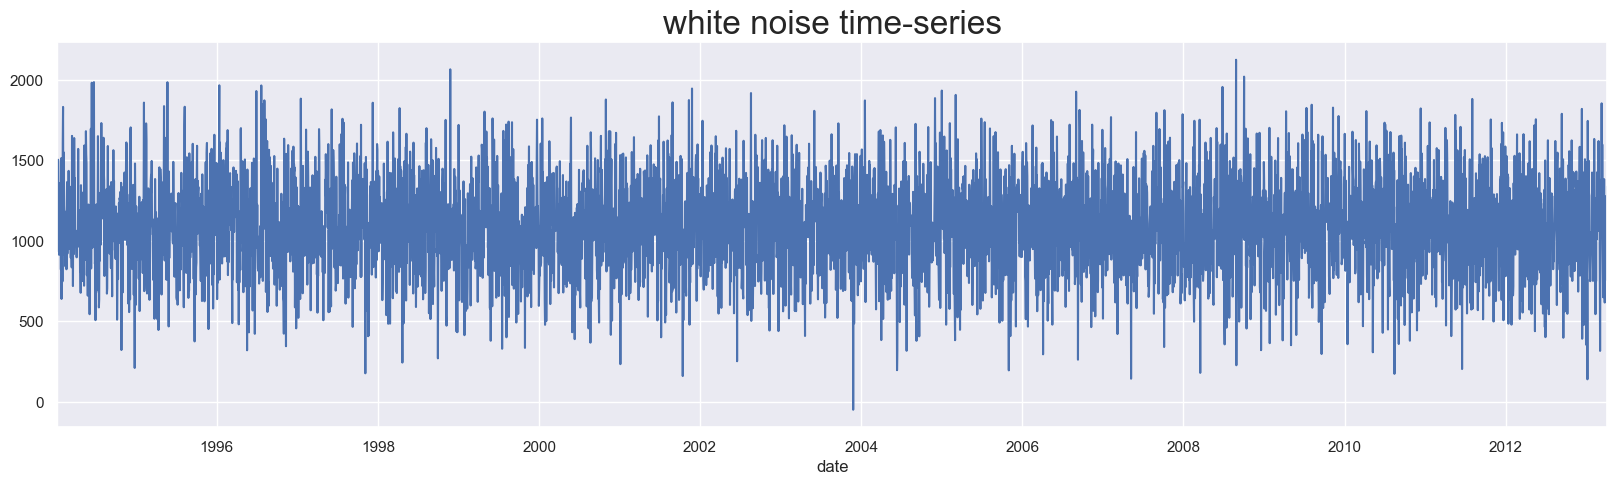

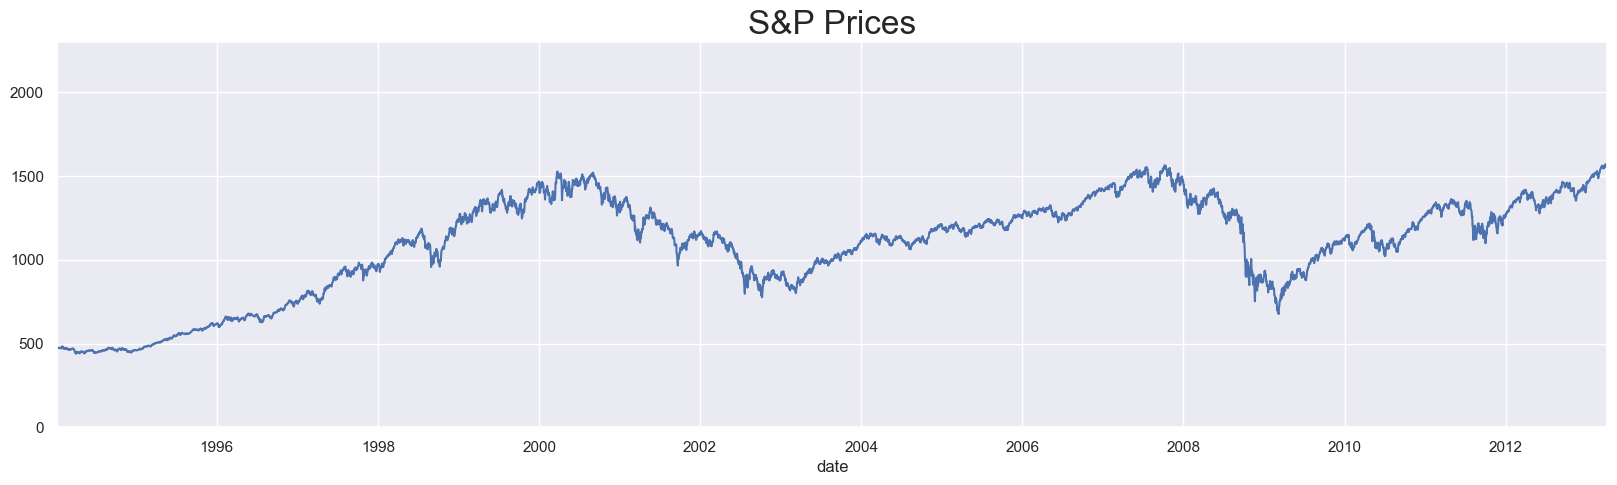

C:\Users\ysriv\AppData\Local\Temp\ipykernel_46596\1450762267.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rw']=rw.price


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
sns.set()
raw_csv_data=pd.read_csv("Index2018.csv")
df_comp=raw_csv_data.copy()
df_comp.date=pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date",inplace=True)
df_comp=df_comp.asfreq("b")
df_comp=df_comp.ffill()
df_comp['market_value']=df_comp.spx
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size=int(len(df_comp)*0.8)
df=df_comp.iloc[:size]
df_test=df_comp.iloc[size:]
wn=np.random.normal(loc=df.market_value.mean(),scale=df.market_value.std(),size=len(df))
df['wn']=wn
df.wn.plot(figsize=(20,5))
plt.title("white noise time-series",size=24)
plt.show()
df.market_value.plot(figsize=(20,5))
plt.title("S&P Prices",size=24)
plt.ylim(0,2300)
plt.show()
rw=pd.read_csv("Randwalk.csv")
rw.date=pd.to_datetime(rw.date, dayfirst=True)
rw.set_index("date",inplace=True)
rw=rw.asfreq('b')
rw.describe()
df['rw']=rw.price

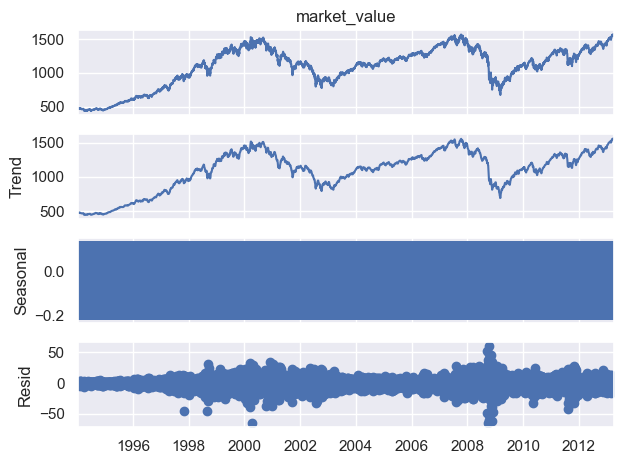

In [3]:
# we will graph the additive naive decomposition and compare it with observed graph
s_dec_additive=seasonal_decompose(df.market_value,model='additive')
s_dec_additive.plot()
plt.show()

## we can see the "trend" closely resembles the "observed" series(because decomposition function uses the previous values as a tyrend setter)
### the trend part of the decomposition explains most of the variability of the data

## 

## --- the seasonal part looks like the rectangle thsi happens when the values are constantly occilating back and forth and the figure size is too small, in our case the linear change result form constantly switching up and down between -0.2 and 0.1 therefore there is no concrete cyclical pattern determine using naive decomposition

## ---the residual is the error of our model estimates essentially they are the difference between the true values and predictions for any period

### conclusion --- ADDITIVE DECOMPOSITION SUGGEST THAT THERE IS NO SEASONALITY IN THE DATA

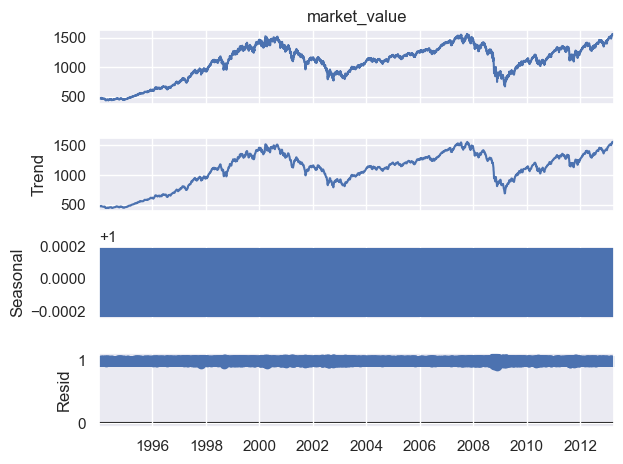

In [4]:
## computing the multiplicative decompostion for double check the result
s_dec_multiplicative=seasonal_decompose(df.market_value,model='multiplicative')
s_dec_multiplicative.plot()
plt.show()

### we see the similar result as additive decomposition there is still no cyclical pattern in seasonal and trend closely resembles the trend of additive decomposition

# CONCLUSION --> THERE IS NO SEASONALITY AMONG S&P PRICES